# Task 1.3 — 8-Fold Cross-Validation Ex-post Analysis

---

## Objective
The goal of this task is to perform an **8-fold cross-validation** to evaluate the robustness of the offering strategy under uncertainty for both one-price and two-price scheme. We want to determine if the optimal bids ($p_t^{DA}$) generated from a limited set of scenarios generalize effectively to unseen market conditions.

---

## Methodology: 8-Fold Cross-Validation
We utilize the full set of 1,600 scenarios and follow these steps:

1. **Data Partitioning (Dual Approach):** Divide the 1,600 scenarios into 8 disjoint sets (folds) of 200 scenarios each. To thoroughly test the strategy, we perform this split twice:
    - **Sequential Split:** Preserves the historically sorted order (low to high yield) to test the model's response to extreme market "regimes."
    - **Randomized Split:** Shuffles the scenarios to ensure each fold is a statistically balanced portion of the overall market.
2. **Iterative Optimization:** For each fold $k \in \{1, \dots, 8\}$:
    - Use fold $k$ as the **In-Sample** ("seen") set (200 scenarios) to solve the profit maximization problem.
    - Define the remaining 1,400 scenarios as the **Out-of-Sample** ("unseen") set.
    - Evaluate the profit of the optimal bid $p_{t,k}^{DA}$ on both the In-Sample and Out-of-Sample sets.
3. **Statistical Evaluation:** Compute the average In-Sample vs. Out-of-Sample expected profits across all 8 runs for both splitting methods to identify potential overfitting.

---

## Key Metrics for Discussion
- **Expected Profit (In-Sample):** The "Optimistic" profit calculated by the solver during optimization.
- **Expected Profit (Out-of-Sample):** The "Realistic" profit when the bid is exposed to unseen data.
- **Generalization Gap:** The difference between In-Sample and Out-of-Sample performance.

# One-price scheme ex-post analysis

Running Sequential Folds...

--- SEQUENTIAL FOLDS (SORTED) SUMMARY ---
   Fold  In-Sample Profit  Out-of-Sample Profit        Gap
0     1          89295.82             518209.42 -428913.60
1     2         196178.11             502940.53 -306762.42
2     3         236104.43             497236.76 -261132.33
3     4         375961.22             477257.22 -101296.00
4     5         451678.34             466440.49  -14762.15
5     6         626946.81             441402.14  185544.67
6     7         723810.82             427564.42  296246.40
7     8        1016786.23             385710.79  631075.43

Average In-Sample Profit:     464595.22 €
Average Out-of-Sample Profit: 464595.22 €
Overall Generalization Gap:   0.00 €

Running Randomized Folds...

--- RANDOMIZED FOLDS (SHUFFLED) SUMMARY ---
   Fold  In-Sample Profit  Out-of-Sample Profit       Gap
0     1         416277.80             471497.71 -55219.91
1     2         499552.11             459601.38  39950.72
2     3         457927.59   

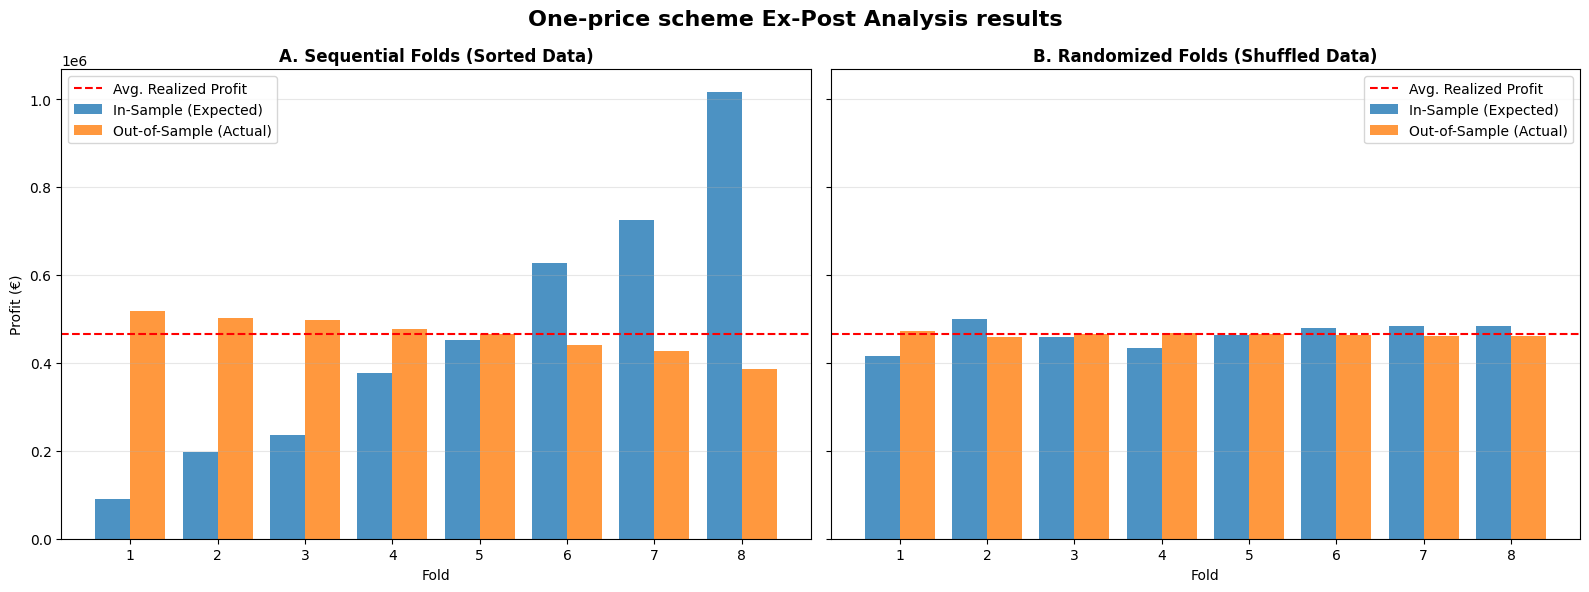

In [10]:
import numpy as np
import pandas as pd
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# ----------------------------
# 1. LOAD DATA & RE-CREATE 1600 SCENARIOS
# ----------------------------
wind = pd.read_csv("../data/processed/wind_realizations.csv") 
price = pd.read_csv("../data/processed/da_price_scenarios.csv")
imbalance = pd.read_csv("../data/processed/imbalance_scenarios_random.csv")

W = wind.iloc[:, 1:].values           
lambda_DA = price.iloc[:, 1:].values  
SI = imbalance.iloc[:, 1:].values     

T = 24
P_max = 500
N_w, N_p, N_s = W.shape[1], lambda_DA.shape[1], SI.shape[1]

W_full = np.repeat(W, N_p * N_s, axis=1)
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))
SI_full = np.tile(SI, (1, N_w * N_p))

lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_total = W_full.shape[1]

# ---------------------------------------------------------
# 2. DEFINE A FUNCTION TO RUN THE CROSS-VALIDATION
# ---------------------------------------------------------
def run_cross_validation(idx_list):
    results = []
    fold_size = 200
    N_folds = 8
    
    for k in range(N_folds):
        start, end = k * fold_size, (k + 1) * fold_size
        idx_in = idx_list[start:end]
        idx_out = np.setdiff1d(idx_list, idx_in)
        
        # Optimization (In-Sample)
        model = gp.Model()
        model.setParam("OutputFlag", 0)
        p_DA_var = model.addVars(T, lb=0, ub=P_max, name="p_DA")
        
        profit_in = 0
        for t in range(T):
            for w in idx_in:
                profit_in += (p_DA_var[t] * lambda_DA_full[t, w] + 
                             (W_full[t, w] - p_DA_var[t]) * lambda_B_full[t, w])
        
        model.setObjective(profit_in / len(idx_in), GRB.MAXIMIZE)
        model.optimize()
        
        p_opt_k = np.array([p_DA_var[t].X for t in range(T)])
        in_sample_profit = model.objVal
        
        # Validation (Out-of-Sample)
        oos_profits = []
        for w in idx_out:
            daily = np.sum(p_opt_k * lambda_DA_full[:, w] + (W_full[:, w] - p_opt_k) * lambda_B_full[:, w])
            oos_profits.append(daily)
            
        out_of_sample_profit = np.mean(oos_profits)
            
        results.append({
            "Fold": k + 1,
            "In-Sample Profit": in_sample_profit,
            "Out-of-Sample Profit": out_of_sample_profit,
            "Gap": in_sample_profit - out_of_sample_profit
        })
        
    return pd.DataFrame(results)

# ---------------------------------------------------------
# 3. RUN TWO DIFFERENT SCENARIOS: SEQUENTIAL FOLDS (SORTED) VS RANDOMIZED FOLDS (SHUFFLED)
# ---------------------------------------------------------
# Run 1: Sequential
print("Running Sequential Folds...")
indices_seq = np.arange(N_total)
df_seq = run_cross_validation(indices_seq)

print("\n============================================================")
print("--- SEQUENTIAL FOLDS (SORTED) SUMMARY ---")
print(df_seq.round(2))
print(f"\nAverage In-Sample Profit:     {df_seq['In-Sample Profit'].mean():.2f} €")
print(f"Average Out-of-Sample Profit: {df_seq['Out-of-Sample Profit'].mean():.2f} €")
print(f"Overall Generalization Gap:   {df_seq['Gap'].mean():.2f} €")
print("============================================================\n")

# Run 2: Randomized
print("Running Randomized Folds...")
indices_rand = np.arange(N_total)
np.random.seed(42) # Ensures the random shuffle is the same every time
np.random.shuffle(indices_rand)
df_rand = run_cross_validation(indices_rand)

print("\n============================================================")
print("--- RANDOMIZED FOLDS (SHUFFLED) SUMMARY ---")
print(df_rand.round(2))
print(f"\nAverage In-Sample Profit:     {df_rand['In-Sample Profit'].mean():.2f} €")
print(f"Average Out-of-Sample Profit: {df_rand['Out-of-Sample Profit'].mean():.2f} €")
print(f"Overall Generalization Gap:   {df_rand['Gap'].mean():.2f} €")
print("============================================================")

# ---------------------------------------------------------
# 4. PLOT SIDE-BY-SIDE BAR CHARTS
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# Add the main title to the figure
fig.suptitle("One-price scheme Ex-Post Analysis results", fontsize=16, fontweight='bold')

# --- Subplot A: Sequential (Bar) ---
axes[0].bar(df_seq['Fold'] - 0.2, df_seq['In-Sample Profit'], width=0.4, label='In-Sample (Expected)', alpha=0.8, color='#1f77b4')
axes[0].bar(df_seq['Fold'] + 0.2, df_seq['Out-of-Sample Profit'], width=0.4, label='Out-of-Sample (Actual)', alpha=0.8, color='#ff7f0e')
axes[0].axhline(df_seq['Out-of-Sample Profit'].mean(), color='red', linestyle='--', label='Avg. Realized Profit')
axes[0].set_title("A. Sequential Folds (Sorted Data)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Profit (€)")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# --- Subplot B: Randomized (Bar) ---
axes[1].bar(df_rand['Fold'] - 0.2, df_rand['In-Sample Profit'], width=0.4, label='In-Sample (Expected)', alpha=0.8, color='#1f77b4')
axes[1].bar(df_rand['Fold'] + 0.2, df_rand['Out-of-Sample Profit'], width=0.4, label='Out-of-Sample (Actual)', alpha=0.8, color='#ff7f0e')
axes[1].axhline(df_rand['Out-of-Sample Profit'].mean(), color='red', linestyle='--', label='Avg. Realized Profit')
axes[1].set_title("B. Randomized Folds (Shuffled Data)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Fold")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Two-price scheme ex-post analysis

Running Sequential Folds (Two-Price)...

--- TWO-PRICE SEQUENTIAL FOLDS SUMMARY ---
   Fold  In-Sample Profit  Out-of-Sample Profit        Gap
0     1         284430.68             528388.76 -243958.09
1     2         409557.41             505521.17  -95963.76
2     3         422347.47             501359.30  -79011.82
3     4         574510.49             478332.49   96178.00
4     5         627198.93             460280.34  166918.59
5     6         821579.20             433665.72  387913.48
6     7         886316.07             422720.65  463595.42
7     8        1191592.47             391801.09  799791.38
Avg In-Sample: 652191.59 €
Avg Out-of-Sample: 465258.69 €
Overall Generalization Gap (G): 186932.90 €

Running Randomized Folds (Two-Price)...

--- TWO-PRICE RANDOMIZED FOLDS SUMMARY ---
   Fold  In-Sample Profit  Out-of-Sample Profit        Gap
0     1         596030.89             473306.77  122724.12
1     2         669738.47             456546.00  213192.47
2     3         62560

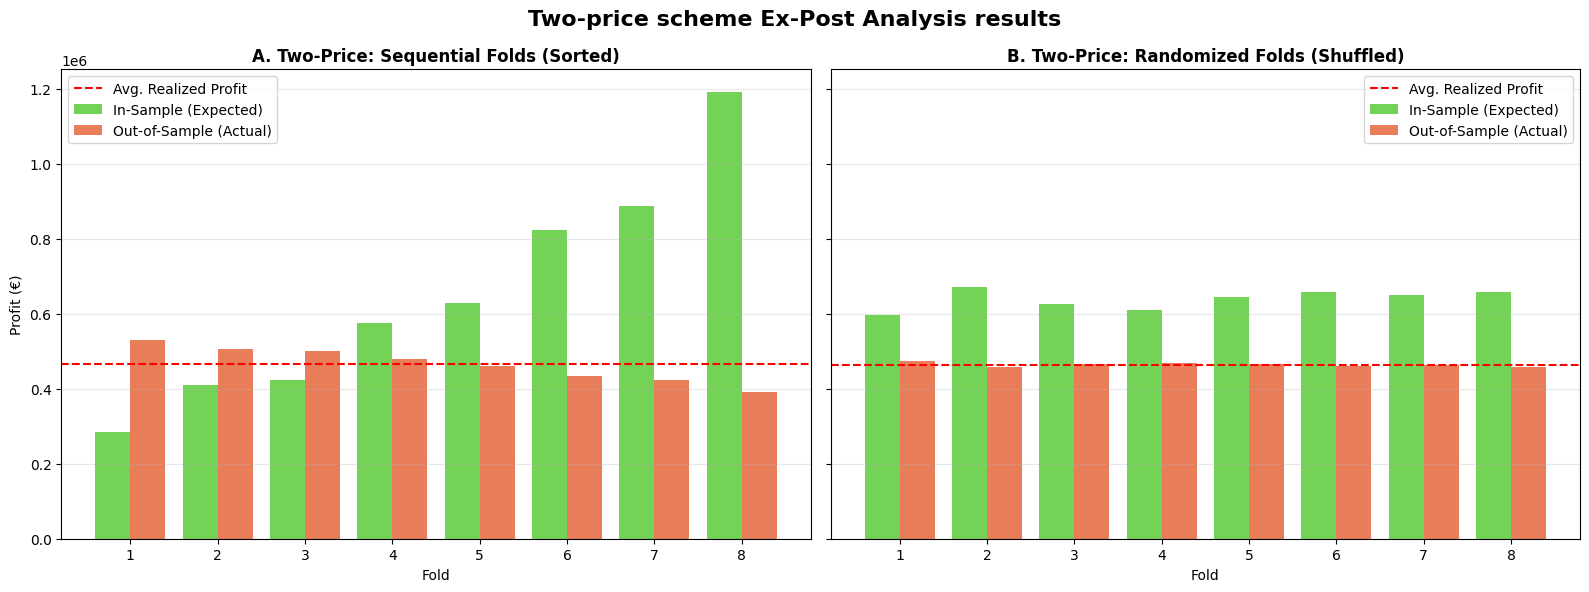

In [11]:

# ----------------------------
# 1. LOAD DATA & RE-CREATE 1600 SCENARIOS
# ----------------------------
# Following Task 1.1 and Task 1.3 methodology[cite: 5, 6]
wind = pd.read_csv("../data/processed/wind_realizations.csv") 
price = pd.read_csv("../data/processed/da_price_scenarios.csv")
imbalance = pd.read_csv("../data/processed/imbalance_scenarios_random.csv")

W = wind.iloc[:, 1:].values           
lambda_DA = price.iloc[:, 1:].values  
SI = imbalance.iloc[:, 1:].values     

T = 24
P_max = 500
N_w, N_p, N_s = W.shape[1], lambda_DA.shape[1], SI.shape[1]

# Construct 1,600 joint scenarios representing independent uncertainty sources[cite: 7]
W_full = np.repeat(W, N_p * N_s, axis=1)
lambda_DA_full = np.tile(np.repeat(lambda_DA, N_s, axis=1), (1, N_w))
SI_full = np.tile(SI, (1, N_w * N_p))

# Settlement price for helpful deviations (balancing price)[cite: 7]
lambda_B_full = np.where(
    SI_full == 1,
    1.25 * lambda_DA_full,
    0.85 * lambda_DA_full
)

N_total = W_full.shape[1]

# ---------------------------------------------------------
# 2. DEFINE FUNCTION FOR TWO-PRICE CROSS-VALIDATION
# ---------------------------------------------------------
def run_two_price_cv(idx_list):
    results = []
    fold_size = 200
    N_folds = 8
    
    for k in range(N_folds):
        start, end = k * fold_size, (k + 1) * fold_size
        idx_in = idx_list[start:end]
        idx_out = np.setdiff1d(idx_list, idx_in)
        
        # --- In-Sample Optimization (200 Scenarios) ---
        # Formulation based on Task 1.2[cite: 6]
        model = gp.Model(f"Fold_{k+1}_InSample")
        model.setParam("OutputFlag", 0)
        
        p_DA = model.addVars(T, lb=0, ub=P_max, name="p_DA")
        # Recourse variables for deviations
        dp = model.addVars(T, len(idx_in), lb=0, ub=P_max, name="dp")
        dm = model.addVars(T, len(idx_in), lb=0, ub=P_max, name="dm")
        
        profit_in = 0
        for t in range(T):
            for i, w_idx in enumerate(idx_in):
                # Imbalance decomposition constraint[cite: 6]
                model.addConstr(dp[t,i] - dm[t,i] == W_full[t,w_idx] - p_DA[t])
                
                # Two-price profit logic: harmful deviations settled at DA price[cite: 6, 7]
                if SI_full[t,w_idx] == 1: # Deficit
                    profit_in += (p_DA[t] * lambda_DA_full[t,w_idx] + 
                                 dp[t,i] * lambda_B_full[t,w_idx] - 
                                 dm[t,i] * lambda_DA_full[t,w_idx])
                else: # Surplus
                    profit_in += (p_DA[t] * lambda_DA_full[t,w_idx] + 
                                 dp[t,i] * lambda_DA_full[t,w_idx] - 
                                 dm[t,i] * lambda_B_full[t,w_idx])
        
        model.setObjective(profit_in / len(idx_in), GRB.MAXIMIZE)
        model.optimize()
        
        p_opt_k = np.array([p_DA[t].X for t in range(T)])
        in_sample_profit = model.objVal
        
        # --- Out-of-Sample Validation (1,400 Scenarios) ---
        oos_profits = []
        for w_idx in idx_out:
            daily_profit = 0
            for t in range(T):
                dev = W_full[t,w_idx] - p_opt_k[t]
                dp_val = max(dev, 0)
                dm_val = max(-dev, 0)
                
                if SI_full[t,w_idx] == 1:
                    daily_profit += (p_opt_k[t] * lambda_DA_full[t,w_idx] + 
                                    dp_val * lambda_B_full[t,w_idx] - 
                                    dm_val * lambda_DA_full[t,w_idx])
                else:
                    daily_profit += (p_opt_k[t] * lambda_DA_full[t,w_idx] + 
                                    dp_val * lambda_DA_full[t,w_idx] - 
                                    dm_val * lambda_B_full[t,w_idx])
            oos_profits.append(daily_profit)
            
        out_of_sample_profit = np.mean(oos_profits)
            
        results.append({
            "Fold": k + 1,
            "In-Sample Profit": in_sample_profit,
            "Out-of-Sample Profit": out_of_sample_profit,
            "Gap": in_sample_profit - out_of_sample_profit
        })
        
    return pd.DataFrame(results)

# ---------------------------------------------------------
# 3. RUN TWO-PRICE EX-POST: SEQUENTIAL VS RANDOMIZED
# ---------------------------------------------------------
# Scenario A: Sequential Folds (Sorted Data)
print("Running Sequential Folds (Two-Price)...")
indices_seq = np.arange(N_total)
df_seq_2p = run_two_price_cv(indices_seq)

print("\n--- TWO-PRICE SEQUENTIAL FOLDS SUMMARY ---")
print(df_seq_2p.round(2))
print(f"Avg In-Sample: {df_seq_2p['In-Sample Profit'].mean():.2f} €")
print(f"Avg Out-of-Sample: {df_seq_2p['Out-of-Sample Profit'].mean():.2f} €")
# Calculate total gap for sequential split
total_gap_seq = df_seq_2p['Gap'].mean()
print(f"Overall Generalization Gap (G): {total_gap_seq:.2f} €")

# Scenario B: Randomized Folds (Shuffled Data)
print("\nRunning Randomized Folds (Two-Price)...")
indices_rand = np.arange(N_total)
np.random.seed(42)
np.random.shuffle(indices_rand)
df_rand_2p = run_two_price_cv(indices_rand)

print("\n--- TWO-PRICE RANDOMIZED FOLDS SUMMARY ---")
print(df_rand_2p.round(2))
print(f"Avg In-Sample: {df_rand_2p['In-Sample Profit'].mean():.2f} €")
print(f"Avg Out-of-Sample: {df_rand_2p['Out-of-Sample Profit'].mean():.2f} €")
# Calculate total gap for randomized split
total_gap_rand = df_rand_2p['Gap'].mean()
print(f"Overall Generalization Gap (G): {total_gap_rand:.2f} €")

# ---------------------------------------------------------
# 4. PLOT SIDE-BY-SIDE COMPARISON
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
# Add the main title to the figure
fig.suptitle("Two-price scheme Ex-Post Analysis results", fontsize=16, fontweight='bold')

# Subplot A: Sequential
axes[0].bar(df_seq_2p['Fold'] - 0.2, df_seq_2p['In-Sample Profit'], width=0.4, label='In-Sample (Expected)', alpha=0.8, color="#51c82d")
axes[0].bar(df_seq_2p['Fold'] + 0.2, df_seq_2p['Out-of-Sample Profit'], width=0.4, label='Out-of-Sample (Actual)', alpha=0.8, color="#e35d31")
axes[0].axhline(df_seq_2p['Out-of-Sample Profit'].mean(), color='red', linestyle='--', label='Avg. Realized Profit')
axes[0].set_title("A. Two-Price: Sequential Folds (Sorted)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Profit (€)")
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Subplot B: Randomized
axes[1].bar(df_rand_2p['Fold'] - 0.2, df_rand_2p['In-Sample Profit'], width=0.4, label='In-Sample (Expected)', alpha=0.8, color='#51c82d')
axes[1].bar(df_rand_2p['Fold'] + 0.2, df_rand_2p['Out-of-Sample Profit'], width=0.4, label='Out-of-Sample (Actual)', alpha=0.8, color='#e35d31')
axes[1].axhline(df_rand_2p['Out-of-Sample Profit'].mean(), color='red', linestyle='--', label='Avg. Realized Profit')
axes[1].set_title("B. Two-Price: Randomized Folds (Shuffled)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Fold")
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Test what happens with the analysis if we increase the number of samples in the folds to N = 400 (4-fold analysis)

Running 4-Fold Randomized Cross-Validation (Two-Price Scheme)...

--- TWO-PRICE 4-FOLD RANDOMIZED SUMMARY ---
   Fold  In-Sample Profit  Out-of-Sample Profit        Gap
0     1         632612.81             466252.72  166360.09
1     2         617526.28             470131.69  147394.59
2     3         651170.94             460972.20  190198.74
3     4         652888.25             456999.72  195888.53

Average In-Sample Profit:     638,549.57 €
Average Out-of-Sample Profit: 463,589.08 €
Overall Generalization Gap (G): 174,960.49 €


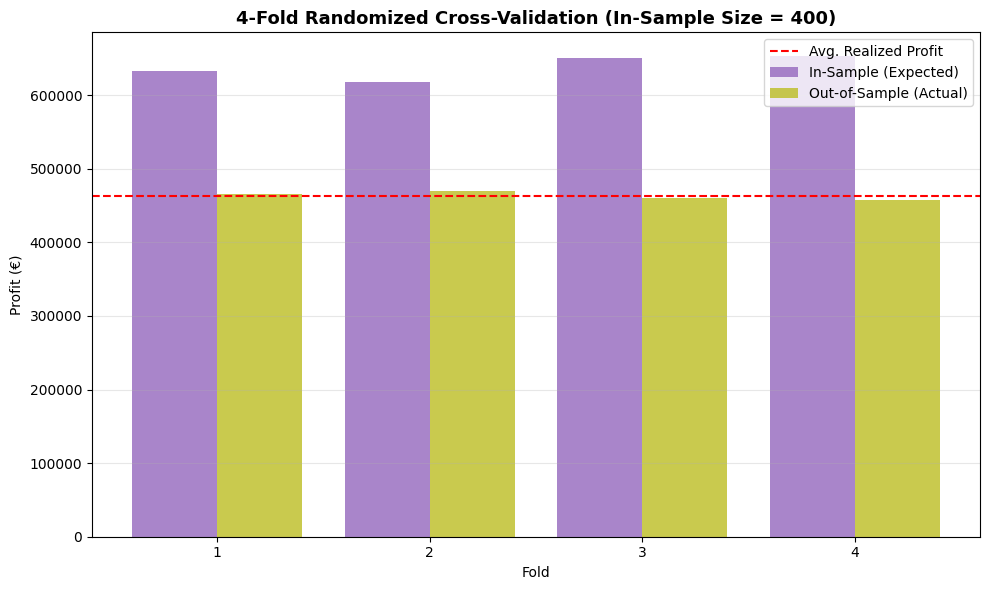

In [8]:

# ---------------------------------------------------------
# 1. PREPARE RANDOMIZED INDICES (400 In-Sample scenarios)
# ---------------------------------------------------------
print("Running 4-Fold Randomized Cross-Validation (Two-Price Scheme)...")
indices_rand_4 = np.arange(N_total)
np.random.seed(42) # Ensuring consistency for randomized comparison
np.random.shuffle(indices_rand_4)

# ---------------------------------------------------------
# 2. DEFINE THE 4-FOLD CROSS-VALIDATION FUNCTION
# ---------------------------------------------------------
def run_cv_4_fold_randomized(idx_list):
    results = []
    fold_size = 400 # Modified from 200 to 400
    N_folds = 4     # Modified from 8 to 4
    
    for k in range(N_folds):
        start, end = k * fold_size, (k + 1) * fold_size
        idx_in = idx_list[start:end]
        idx_out = np.setdiff1d(idx_list, idx_in)
        
        # --- Optimization (In-Sample: 400 scenarios) ---
        # Based on Task 1.2 formulation with asymmetric penalties
        model = gp.Model(f"Fold_400_{k+1}")
        model.setParam("OutputFlag", 0)
        
        p_DA = model.addVars(T, lb=0, ub=P_max, name="p_DA")
        dp = model.addVars(T, len(idx_in), lb=0, ub=P_max, name="dp")
        dm = model.addVars(T, len(idx_in), lb=0, ub=P_max, name="dm")
        
        profit_in = 0
        for t in range(T):
            for i, w_idx in enumerate(idx_in):
                # Linking deviations to wind production and bids
                model.addConstr(dp[t,i] - dm[t,i] == W_full[t,w_idx] - p_DA[t])
                
                # Asymmetric profit calculation based on system imbalance
                if SI_full[t,w_idx] == 1: # System Deficit
                    profit_in += (p_DA[t] * lambda_DA_full[t,w_idx] + 
                                 dp[t,i] * lambda_B_full[t,w_idx] - 
                                 dm[t,i] * lambda_DA_full[t,w_idx])
                else: # System Surplus
                    profit_in += (p_DA[t] * lambda_DA_full[t,w_idx] + 
                                 dp[t,i] * lambda_DA_full[t,w_idx] - 
                                 dm[t,i] * lambda_B_full[t,w_idx])
        
        model.setObjective(profit_in / len(idx_in), GRB.MAXIMIZE)
        model.optimize()
        
        p_opt_k = np.array([p_DA[t].X for t in range(T)])
        in_sample_profit = model.objVal
        
        # --- Validation (Out-of-Sample: 1200 scenarios) ---
        oos_profits = []
        for w_idx in idx_out:
            daily_profit = 0
            for t in range(T):
                dev = W_full[t,w_idx] - p_opt_k[t]
                dp_val = max(dev, 0)
                dm_val = max(-dev, 0)
                
                # Applying settlement logic to unseen data
                if SI_full[t,w_idx] == 1:
                    daily_profit += (p_opt_k[t] * lambda_DA_full[t,w_idx] + 
                                    dp_val * lambda_B_full[t,w_idx] - 
                                    dm_val * lambda_DA_full[t,w_idx])
                else:
                    daily_profit += (p_opt_k[t] * lambda_DA_full[t,w_idx] + 
                                    dp_val * lambda_DA_full[t,w_idx] - 
                                    dm_val * lambda_B_full[t,w_idx])
            oos_profits.append(daily_profit)
            
        out_of_sample_profit = np.mean(oos_profits)
            
        results.append({
            "Fold": k + 1,
            "In-Sample Profit": in_sample_profit,
            "Out-of-Sample Profit": out_of_sample_profit,
            "Gap": in_sample_profit - out_of_sample_profit
        })
        
    return pd.DataFrame(results)

# ---------------------------------------------------------
# 3. EXECUTE, PRINT SUMMARY, AND PLOT
# ---------------------------------------------------------
df_cv_4 = run_cv_4_fold_randomized(indices_rand_4)

print("\n--- TWO-PRICE 4-FOLD RANDOMIZED SUMMARY ---")
print(df_cv_4.round(2))

# Calculating and printing averages and Generalization Gap
avg_in = df_cv_4['In-Sample Profit'].mean()
avg_out = df_cv_4['Out-of-Sample Profit'].mean()
total_gap = df_cv_4['Gap'].mean()

print(f"\nAverage In-Sample Profit:     {avg_in:,.2f} €")
print(f"Average Out-of-Sample Profit: {avg_out:,.2f} €")
print(f"Overall Generalization Gap (G): {total_gap:,.2f} €")

# ---------------------------------------------------------
# 4. PLOT RESULTS
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
folds = df_cv_4['Fold']
plt.bar(folds - 0.2, df_cv_4['In-Sample Profit'], width=0.4, label='In-Sample (Expected)', color='#9467bd', alpha=0.8)
plt.bar(folds + 0.2, df_cv_4['Out-of-Sample Profit'], width=0.4, label='Out-of-Sample (Actual)', color='#bcbd22', alpha=0.8)

plt.axhline(avg_out, color='red', linestyle='--', label='Avg. Realized Profit')
plt.title("4-Fold Randomized Cross-Validation (In-Sample Size = 400)", fontsize=13, fontweight='bold')
plt.xlabel("Fold")
plt.ylabel("Profit (€)")
plt.xticks(folds)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5. Discussion of Ex-post analysis Results

#### 5.1. Analysis of the Profit Trends
The side-by-side comparison of the 8-fold cross-validation reveals how the settlement logic and data ordering impact the perceived performance of the model:

*   **One-Price Scheme Trends:** 

    *   **Sequential Folds (The "Staircase" Effect):** When scenarios are pre-sorted by yield, we observe a sharp upward trend in training profits—ranging from **€89,295.82** in Fold 1 to **€1,016,786.23** in Fold 8. The early folds are artificially trapped in low-revenue regimes, while the later folds contain exclusively high-revenue realizations.
    *   **Randomized Folds:** Shuffling creates a balanced microcosm of the market in every fold, causing the In-Sample profit to flatten out and mirror the global average.
*   **Two-Price Scheme Trends:** 

    *   **Sequential Folds:** similar to the one-price scheme, the two-price sequential split shows an extreme range driven by the data sorting, from **€284,430.68** (Fold 1) to **€1,191,592.47** (Fold 8).
    *   **Randomized Folds:** Unlike the one-price scheme, the two-price randomized training results remain consistently and significantly higher than the realized out-of-sample results, fluctuating between **€596,030.89** and **€669,738.47**.
*   **Out-of-Sample Consistency:** In both market schemes and across both splitting methods, the realized Out-of-Sample profit remains remarkably stable, averaging approximately **€464,595.22** for the one-price scheme and **€463,883.23** for the two-price scheme. This stability confirms that a 1,400-scenario validation set effectively represents the full statistical distribution of the market.

#### 5.2. The Generalization Gap
The **Generalization Gap** ($G$) measures the difference between expected performance on seen (In-Sample) data versus unseen (Out-of-Sample) data:

$$G = \mathbb{E}[\Pi_{\omega \in \Omega^{in}}] - \mathbb{E}[\Pi_{\omega \in \Omega^{out}}]$$

*   **One-Price Scheme:** The **Overall Generalization Gap is 0.00 €**. Because the optimal strategy follows a linear "all-or-nothing" structure, the model identifies the exact same underlying market logic regardless of the specific 200-scenario training slice.

*   **Two-Price Scheme:** A significant **Overall Generalization Gap of 174,846.05 €** is observed in the randomized folds. The asymmetric penalties of the two-price scheme create a complex "newsvendor" trade-off. This complexity makes the solver highly sensitive to the specific realizations in the training set, leading to "optimistic" bids that overfit to small-sample noise and do not fully generalize to unseen data.

#### 5.3. Evaluation of Sample Size and Robustness
*   **Is 200 scenarios enough?** 

    *   For the **one-price scheme**, yes. The 0.00 € gap proves the strategy's absolute stability even when trained on only 12.5% of the total scenarios. 
    *   For the **two-price scheme**, no. The high generalization gap indicates that 200 scenarios are insufficient to capture the statistical complexity of the asymmetric settlement rules without overfitting.
*   **Decision Quality:** While the one-price strategy is perfectly generalized, the two-price strategy shows that decision quality is hampered by small-sample bias. For a risk-neutral producer, the two-price logic requires a larger in-sample size to "learn" a bidding strategy that is as robust as the one-price benchmark.

#### 5.4. Final Conclusion
This cross-validation confirms that while the one-price scheme is statistically robust, the transition to a two-price scheme introduces significant modeling challenges under uncertainty. Both schemes demonstrate that risk-neutral strategies offer no protection against the punishing low-revenue periods identified in the sequential Fold 1 results. This persistent revenue volatility and the overfitting observed in the two-price scheme provide a strong justification for transitioning to a **Risk-Averse Offering Strategy with CVaR analysis** in Task 1.4.